# Análise Exploratória de Dados (EDA)
Notebook simples para análise das vendas.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = pd.read_csv("/mnt/data/vendas_rede_lojas.csv")
df.head()

,Data,Loja,Regiao,Produto,Categoria,Quantidade,Preco_Unitario,Desconto_%,Valor_Total,Vendedor
0,2024-01-15,Loja Centro,Centro,Notebook,Eletrônicos,5.0,450.50,10.5,2014.74,Ana Silva
1,2024-01-20,Loja Norte,Norte,Smartphone,Eletrônicos,2.0,1200.00,NaN,2400.00,Bruno Costa
2,2024-01-25,Loja Sul,Sul,Tablet,Informática,NaN,350.75,15.0,NaN,NaN
3,2024-02-01,Loja Leste,Leste,Mouse,Acessórios,10.0,25.90,NaN,259.00,Carla Santos
4,2024-02-05,Loja Oeste,Oeste,Teclado,Acessórios,8.0,85.00,5.0,646.00,Diego Oliveira


## Informações do dataset

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Data            391 non-null    object 
 1   Loja            391 non-null    object 
 2   Regiao          391 non-null    object 
 3   Produto         391 non-null    object 
 4   Categoria       391 non-null    object 
 5   Quantidade      337 non-null    float64
 6   Preco_Unitario  391 non-null    float64
 7   Desconto_%      226 non-null    float64
 8   Valor_Total     336 non-null    float64
 9   Vendedor        336 non-null    object 
dtypes: float64(4), object(6)
memory usage: 30.7+ KB


## Limpeza dos dados

In [3]:
df["Desconto_%"]=df["Desconto_%"].fillna(df["Desconto_%"].median())
df["Quantidade"]=df["Quantidade"].fillna(df["Quantidade"].median())
df["Preco_Unitario"]=df["Preco_Unitario"].fillna(df["Preco_Unitario"].median())
df=df.drop("Vendedor",axis=1)
df["Data"]=pd.to_datetime(df["Data"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Data            391 non-null    datetime64[ns]
 1   Loja            391 non-null    object        
 2   Regiao          391 non-null    object        
 3   Produto         391 non-null    object        
 4   Categoria       391 non-null    object        
 5   Quantidade      391 non-null    float64       
 6   Preco_Unitario  391 non-null    float64       
 7   Desconto_%      391 non-null    float64       
 8   Valor_Total     336 non-null    float64       
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 27.6+ KB


## Criando novas colunas

In [4]:
df["Valor_Total"]=(df["Quantidade"]*df["Preco_Unitario"])*(1-df["Desconto_%"]/100)
df["Valor_Bruto"]=df["Quantidade"]*df["Preco_Unitario"]

## Estatísticas

In [5]:
print(df["Valor_Total"].describe())
df.describe()

count       391.000000
mean       8793.469399
std       18844.535099
min         220.150000
25%        1282.930000
50%        2760.000000
75%        6800.000000
max      175500.000000
Name: Valor_Total, dtype: float64


,Data,Quantidade,Preco_Unitario,Desconto_%,Valor_Total,Valor_Bruto
count,391,391.000000,391.000000,391.000000,391.000000,391.000000
mean,2024-07-07 14:07:03.529411584,16.281330,1983.447954,15.924552,8793.469399,10999.037724
min,2024-01-02 00:00:00,1.000000,20.000000,5.000000,220.150000,259.000000
25%,2024-04-08 12:00:00,7.000000,100.500000,13.000000,1282.930000,1494.000000
50%,2024-07-12 00:00:00,13.000000,310.000000,15.000000,2760.000000,3315.000000
75%,2024-10-07 12:00:00,22.000000,1700.000000,16.000000,6800.000000,8400.000000
max,2024-12-31 00:00:00,57.000000,45000.000000,70.000000,175500.000000,270000.000000
std,NaN,12.911241,5006.752185,7.646773,18844.535099,25009.746111


## Outliers (IQR)

In [6]:
q1=df["Valor_Total"].quantile(0.25)
q3=df["Valor_Total"].quantile(0.75)
iqr=q3-q1
li=q1-1.5*iqr
ls=q3+1.5*iqr
outliers=df[(df["Valor_Total"]<li)|(df["Valor_Total"]>ls)]
print("Quantidade de outliers:",len(outliers))

Quantidade de outliers: 52


## Análise por categoria

In [7]:
print(df.groupby("Categoria")["Valor_Total"].mean().round(2))
print(df.groupby("Categoria")["Quantidade"].median())

Categoria
Acessórios      1347.39
Eletrônicos    22727.18
Informática     4668.77
Name: Valor_Total, dtype: float64
Categoria
Acessórios     26.0
Eletrônicos     4.0
Informática    11.0
Name: Quantidade, dtype: float64


## Gráficos

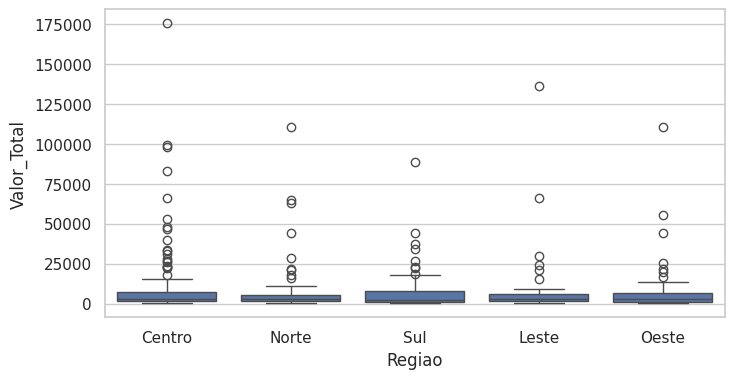

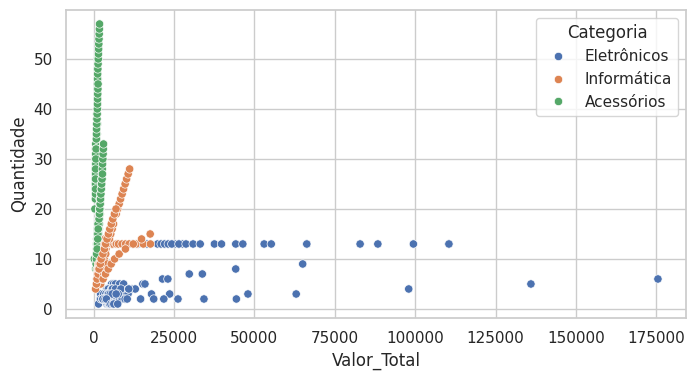

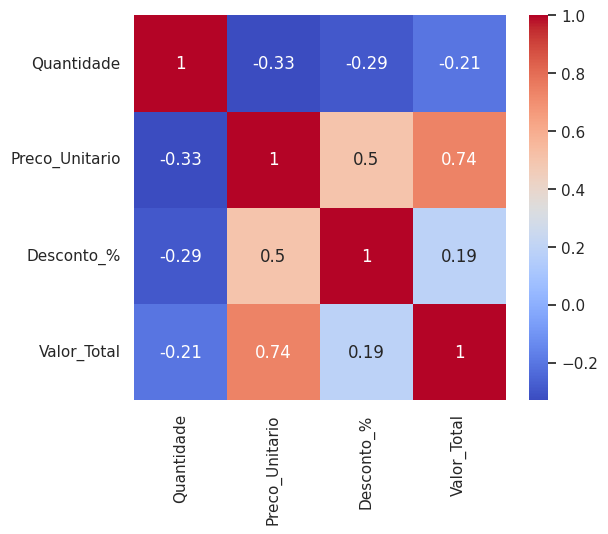

In [8]:
plt.figure(figsize=(8,4))
sns.boxplot(x="Regiao",y="Valor_Total",data=df)
plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(data=df,x="Valor_Total",y="Quantidade",hue="Categoria")
plt.show()

corr=df[["Quantidade","Preco_Unitario","Desconto_%","Valor_Total"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

## Análise temporal

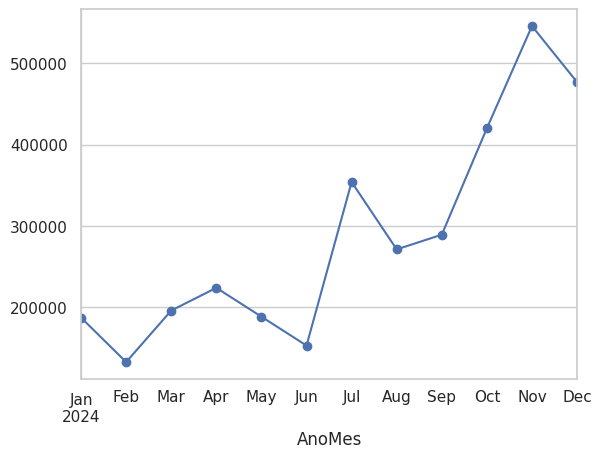

In [9]:
df["AnoMes"]=df["Data"].dt.to_period("M")
df.groupby("AnoMes")["Valor_Total"].sum().plot(marker="o")
plt.show()

## Conclusão
- Dados ausentes tratados com a mediana.
- Foram encontrados outliers.
- Eletrônicos apresentou maior valor médio de vendas.
- A análise temporal ajuda a visualizar a evolução das vendas.